In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df=pd.read_csv("C:\\Users\\Karthikeya\\Downloads\\rohit_sharma_career_practice_1000.csv")
df=df.drop(columns=["Player","Match_Number","Match_ID","Data_Type"])
df

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings
0,2007,ODI,International Cricket,India,England,Kingsmead,South Africa,No,122,183,66.67,Run Out,Out,Won,1
1,2007,ODI,International Cricket,India,Afghanistan,M. Chinnaswamy Stadium,India,No,95,125,76.00,LBW,Out,Won,1
2,2007,IPL,Indian Premier League,Deccan Chargers,Chennai Super Kings,Arun Jaitley Stadium,India,No,19,14,135.71,Bowled,Out,Won,1
3,2007,IPL,Indian Premier League,Mumbai Indians,Lucknow Super Giants,Arun Jaitley Stadium,India,No,34,27,125.93,Caught,Out,Won,1
4,2007,IPL,Indian Premier League,Deccan Chargers,Lucknow Super Giants,Arun Jaitley Stadium,India,No,57,62,91.94,Caught,Out,Won,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026,T20I,International Cricket,India,Nepal,Sher-e-Bangla National Cricket Stadium,Bangladesh,No,16,18,88.89,Caught,Out,Lost,1
996,2026,IPL,Indian Premier League,Deccan Chargers,Sunrisers Hyderabad,Rajiv Gandhi International Stadium,India,No,3,13,23.08,Caught,Out,Won,1
997,2026,ODI,International Cricket,India,West Indies,Kingsmead,South Africa,No,58,68,85.29,Bowled,Out,Lost,1
998,2026,ODI,International Cricket,India,Bangladesh,Wankhede Stadium,India,No,19,17,111.76,Caught,Out,Won,1


In [114]:
df.isnull().sum()

Year              0
Format            0
League            0
Team              0
Opponent          0
Ground_Name       0
Ground_Country    0
Captain           0
Runs              0
Balls             0
Strike_Rate       0
Dismissal         0
Out_Status        0
Match_Result      0
Innings           0
dtype: int64

In [115]:
df.duplicated().sum()

0

In [138]:
outs=df.groupby("Dismissal")[["Outs/NotOut"]].sum().reset_index()

In [140]:
outs

,Dismissal,Outs/NotOut
0,Bowled,165
1,Caught,472
2,LBW,96
3,Not Out,159
4,Run Out,71
5,Stumped,37


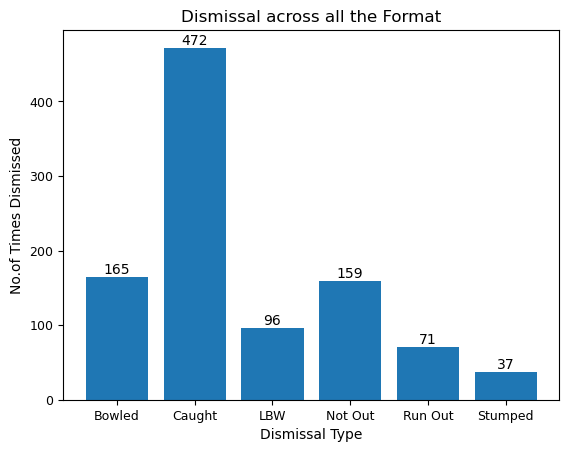

In [331]:
bars=plt.bar(outs["Dismissal"],outs["Outs/NotOut"])
plt.bar_label(bars,fontsize=10)
plt.xlabel("Dismissal Type")
plt.ylabel("No.of Times Dismissed")
plt.title("Dismissal across all the Format")
plt.xticks(fontsize=9,rotation=0)
plt.yticks(fontsize=9)
plt.show()

In [122]:
df["Outs/NotOut"]=np.where(df["Out_Status"],1,0)

In [124]:
formats=df["Format"].value_counts().reset_index()

In [126]:
formats

,Format,count
0,ODI,433
1,IPL,389
2,T20I,91
3,Test,87


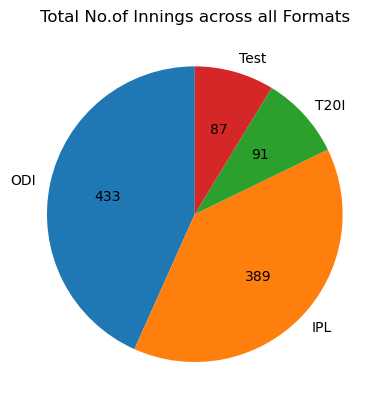

In [341]:
plt.pie(formats["count"],labels=formats["Format"],autopct=lambda p: f'{int(round(p*sum(formats["count"])/100))}',startangle=90)
plt.title("Total No.of Innings across all Formats")
plt.show()

In [128]:
captain=df["Captain"].value_counts().reset_index()
captain

,Captain,count
0,No,620
1,Yes,380


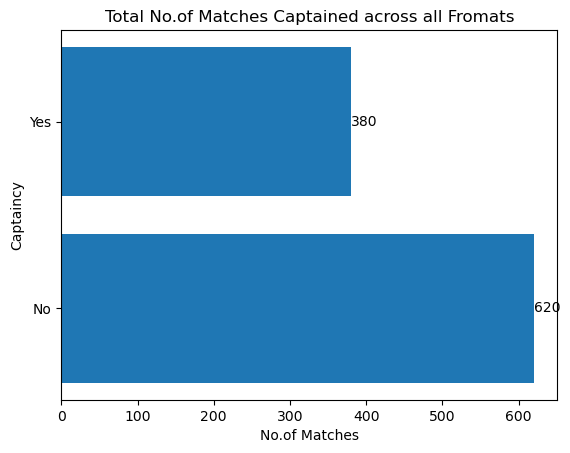

In [347]:
barh=plt.barh(captain["Captain"],captain['count'])
plt.bar_label(barh,fontsize=10)
plt.title("Total No.of Matches Captained across all Fromats")
plt.xlabel("No.of Matches")
plt.ylabel("Captaincy")
plt.show()

In [132]:
format_runs=df.groupby("Format")[["Runs"]].sum().reset_index()
format_runs

,Format,Runs
0,IPL,10163
1,ODI,17415
2,T20I,2337
3,Test,3325


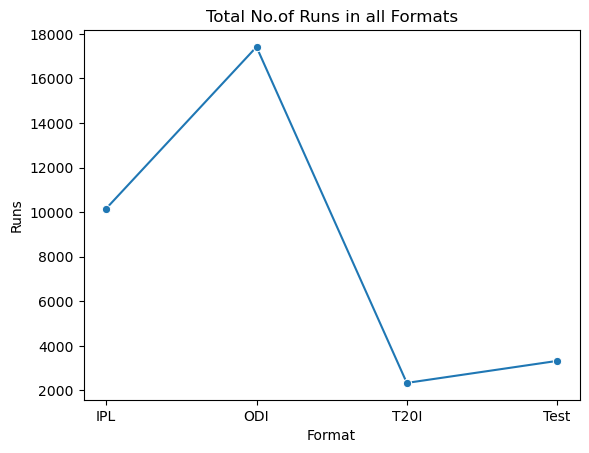

In [356]:
bar=sns.lineplot(data=format_runs,x="Format",y="Runs",marker='o')
plt.title("Total No.of Runs in all Formats")
plt.show()

In [152]:
df["Match_Result"].unique()

array(['Won', 'Lost'], dtype=object)

In [154]:
df["Fifties"]=np.where((df["Runs"]>=50) & (df["Runs"]<=99),1,0)
df["Hundreds"]=np.where((df["Runs"]>=100) & (df["Runs"]<=199),1,0)
df["Double_Hundreds"]=np.where(df["Runs"]>=200,1,0)
df["Match_Status"]=np.where(df["Match_Result"]=="Won",1,0)

In [156]:
df

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
0,2007,ODI,International Cricket,India,England,Kingsmead,South Africa,No,122,183,66.67,Run Out,Out,Won,1,1,1,0,0,1
1,2007,ODI,International Cricket,India,Afghanistan,M. Chinnaswamy Stadium,India,No,95,125,76.00,LBW,Out,Won,1,1,0,0,1,1
2,2007,IPL,Indian Premier League,Deccan Chargers,Chennai Super Kings,Arun Jaitley Stadium,India,No,19,14,135.71,Bowled,Out,Won,1,1,0,0,0,1
3,2007,IPL,Indian Premier League,Mumbai Indians,Lucknow Super Giants,Arun Jaitley Stadium,India,No,34,27,125.93,Caught,Out,Won,1,1,0,0,0,1
4,2007,IPL,Indian Premier League,Deccan Chargers,Lucknow Super Giants,Arun Jaitley Stadium,India,No,57,62,91.94,Caught,Out,Won,1,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026,T20I,International Cricket,India,Nepal,Sher-e-Bangla National Cricket Stadium,Bangladesh,No,16,18,88.89,Caught,Out,Lost,1,1,0,0,0,0
996,2026,IPL,Indian Premier League,Deccan Chargers,Sunrisers Hyderabad,Rajiv Gandhi International Stadium,India,No,3,13,23.08,Caught,Out,Won,1,1,0,0,0,1
997,2026,ODI,International Cricket,India,West Indies,Kingsmead,South Africa,No,58,68,85.29,Bowled,Out,Lost,1,1,0,0,1,0
998,2026,ODI,International Cricket,India,Bangladesh,Wankhede Stadium,India,No,19,17,111.76,Caught,Out,Won,1,1,0,0,0,1


In [358]:
hundreds=df.groupby("Format")[['Fifties','Hundreds']].sum().reset_index()
hundreds

,Format,Fifties,Hundreds
0,IPL,45,5
1,ODI,102,30
2,T20I,12,0
3,Test,21,4


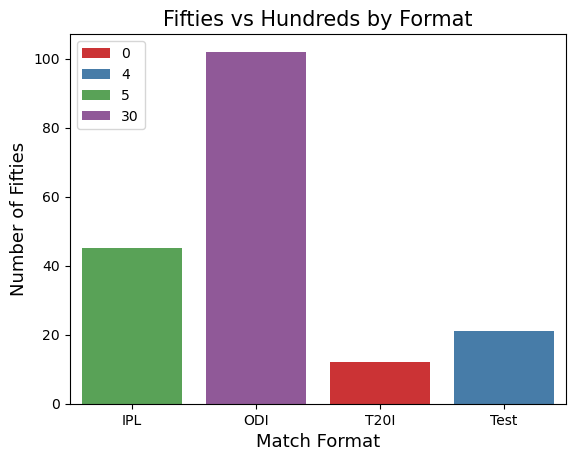

In [378]:
sns.barplot(data=hundreds, x="Format", y="Fifties", hue="Hundreds",palette="Set1")
plt.xlabel("Match Format", fontsize=13)
plt.ylabel("Number of Fifties", fontsize=13)
plt.title("Fifties vs Hundreds by Format", fontsize=15)
plt.legend(loc=2)
plt.show()


In [180]:
dfc=df[df["Captain"]=="Yes"]
dfc

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
248,2013,IPL,Indian Premier League,Mumbai Indians,Gujarat Titans,Arun Jaitley Stadium,India,Yes,44,45,97.78,Not Out,Not Out,Lost,1,1,0,0,0,0
249,2013,IPL,Indian Premier League,Mumbai Indians,Gujarat Titans,MA Chidambaram Stadium,India,Yes,9,6,150.00,Caught,Out,Won,1,1,0,0,0,1
252,2013,IPL,Indian Premier League,Mumbai Indians,Rajasthan Royals,Wankhede Stadium,India,Yes,49,36,136.11,Caught,Out,Lost,1,1,0,0,0,0
254,2013,IPL,Indian Premier League,Mumbai Indians,Punjab Kings,MA Chidambaram Stadium,India,Yes,17,15,113.33,Caught,Out,Won,1,1,0,0,0,1
263,2013,IPL,Indian Premier League,Mumbai Indians,Chennai Super Kings,Eden Gardens,India,Yes,34,30,113.33,Bowled,Out,Lost,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,2026,IPL,Indian Premier League,Mumbai Indians,Rajasthan Royals,Wankhede Stadium,India,Yes,28,34,82.35,Caught,Out,Won,1,1,0,0,0,1
984,2026,IPL,Indian Premier League,Mumbai Indians,Sunrisers Hyderabad,Eden Gardens,India,Yes,53,57,92.98,Not Out,Not Out,Lost,1,1,0,0,1,0
992,2026,IPL,Indian Premier League,Mumbai Indians,Rajasthan Royals,Eden Gardens,India,Yes,18,21,85.71,Bowled,Out,Won,1,1,0,0,0,1
993,2026,IPL,Indian Premier League,Mumbai Indians,Sunrisers Hyderabad,Rajiv Gandhi International Stadium,India,Yes,44,29,151.72,LBW,Out,Lost,1,1,0,0,0,0


In [174]:
winning_captain=dfc.groupby("Captain")[["Match_Result"]].value_counts().reset_index()
winning_captain

,Captain,Match_Result,count
0,Yes,Won,233
1,Yes,Lost,147


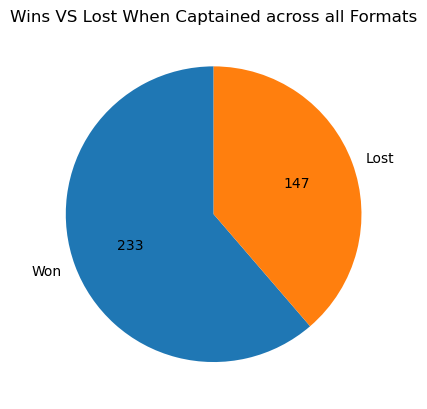

In [390]:
plt.pie(winning_captain["count"],labels=winning_captain["Match_Result"],startangle=90,autopct=lambda p: f'{int(round(p*sum(winning_captain["count"])/100))}')
plt.title("Wins VS Lost When Captained across all Formats")
plt.show()

In [182]:
dfnc=df[df["Captain"]=="No"]
dfnc

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
0,2007,ODI,International Cricket,India,England,Kingsmead,South Africa,No,122,183,66.67,Run Out,Out,Won,1,1,1,0,0,1
1,2007,ODI,International Cricket,India,Afghanistan,M. Chinnaswamy Stadium,India,No,95,125,76.00,LBW,Out,Won,1,1,0,0,1,1
2,2007,IPL,Indian Premier League,Deccan Chargers,Chennai Super Kings,Arun Jaitley Stadium,India,No,19,14,135.71,Bowled,Out,Won,1,1,0,0,0,1
3,2007,IPL,Indian Premier League,Mumbai Indians,Lucknow Super Giants,Arun Jaitley Stadium,India,No,34,27,125.93,Caught,Out,Won,1,1,0,0,0,1
4,2007,IPL,Indian Premier League,Deccan Chargers,Lucknow Super Giants,Arun Jaitley Stadium,India,No,57,62,91.94,Caught,Out,Won,1,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026,T20I,International Cricket,India,Nepal,Sher-e-Bangla National Cricket Stadium,Bangladesh,No,16,18,88.89,Caught,Out,Lost,1,1,0,0,0,0
996,2026,IPL,Indian Premier League,Deccan Chargers,Sunrisers Hyderabad,Rajiv Gandhi International Stadium,India,No,3,13,23.08,Caught,Out,Won,1,1,0,0,0,1
997,2026,ODI,International Cricket,India,West Indies,Kingsmead,South Africa,No,58,68,85.29,Bowled,Out,Lost,1,1,0,0,1,0
998,2026,ODI,International Cricket,India,Bangladesh,Wankhede Stadium,India,No,19,17,111.76,Caught,Out,Won,1,1,0,0,0,1


In [184]:
winning_not_as_captain=dfnc.groupby(["Captain"])[["Match_Result"]].value_counts().reset_index()
winning_not_as_captain

,Captain,Match_Result,count
0,No,Won,404
1,No,Lost,216


In [196]:
Strike_Rate=df.groupby("Format")[["Strike_Rate"]].mean().reset_index()
Strike_Rate

,Format,Strike_Rate
0,IPL,103.751465
1,ODI,80.931894
2,T20I,102.951648
3,Test,59.735747


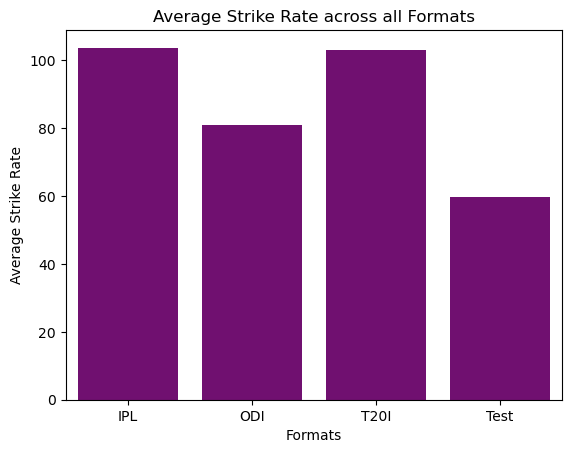

In [402]:
sns.barplot(data=Strike_Rate,x="Format",y="Strike_Rate",color="purple")
plt.title("Average Strike Rate across all Formats")
plt.xlabel("Formats")
plt.ylabel("Average Strike Rate")
plt.show()

In [311]:
most_runs_country_in_allFormats=df.groupby("Ground_Country")[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
most_runs_country_in_allFormats

,Ground_Country,Runs
0,India,18144
1,England,2613
2,New Zealand,2436
3,South Africa,2324
4,Australia,2014
5,Bangladesh,1672
6,West Indies,1492
7,UAE,1328
8,Sri Lanka,1217


C:\Users\Karthikeya\AppData\Local\Temp\ipykernel_45696\3871921879.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_runs_country_in_allFormats,x="Ground_Country",y="Runs",palette='Set1')


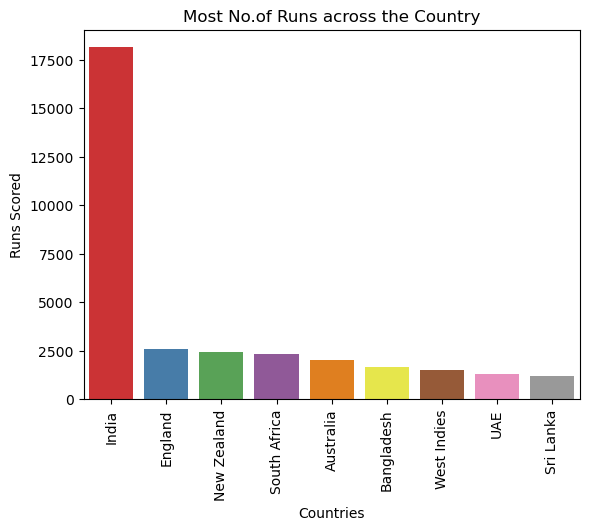

In [406]:
sns.barplot(data=most_runs_country_in_allFormats,x="Ground_Country",y="Runs",palette='Set1')
plt.title("Most No.of Runs across the Country")
plt.xlabel("Countries")
plt.xticks(rotation=90)
plt.ylabel("Runs Scored")
plt.show()

In [212]:
dfl=df[df["League"]=="International Cricket"]
dfl

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
0,2007,ODI,International Cricket,India,England,Kingsmead,South Africa,No,122,183,66.67,Run Out,Out,Won,1,1,1,0,0,1
1,2007,ODI,International Cricket,India,Afghanistan,M. Chinnaswamy Stadium,India,No,95,125,76.00,LBW,Out,Won,1,1,0,0,1,1
5,2007,ODI,International Cricket,India,Afghanistan,Arun Jaitley Stadium,India,No,33,37,89.19,Bowled,Out,Lost,1,1,0,0,0,0
6,2007,Test,International Cricket,India,South Africa,Arun Jaitley Stadium,India,No,59,97,60.82,Caught,Out,Lost,1,1,0,0,1,0
8,2007,ODI,International Cricket,India,Bangladesh,St George's Park,South Africa,No,39,59,66.10,Caught,Out,Won,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,2026,ODI,International Cricket,India,Pakistan,Arun Jaitley Stadium,India,No,5,1,500.00,Caught,Out,Won,1,1,0,0,0,1
995,2026,T20I,International Cricket,India,Nepal,Sher-e-Bangla National Cricket Stadium,Bangladesh,No,16,18,88.89,Caught,Out,Lost,1,1,0,0,0,0
997,2026,ODI,International Cricket,India,West Indies,Kingsmead,South Africa,No,58,68,85.29,Bowled,Out,Lost,1,1,0,0,1,0
998,2026,ODI,International Cricket,India,Bangladesh,Wankhede Stadium,India,No,19,17,111.76,Caught,Out,Won,1,1,0,0,0,1


In [307]:
most_runs_country_in_international=dfl.groupby("Ground_Country")[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
most_runs_country_in_international

,Ground_Country,Runs
0,India,7981
1,England,2613
2,New Zealand,2436
3,South Africa,2324
4,Australia,2014
5,Bangladesh,1672
6,West Indies,1492
7,UAE,1328
8,Sri Lanka,1217


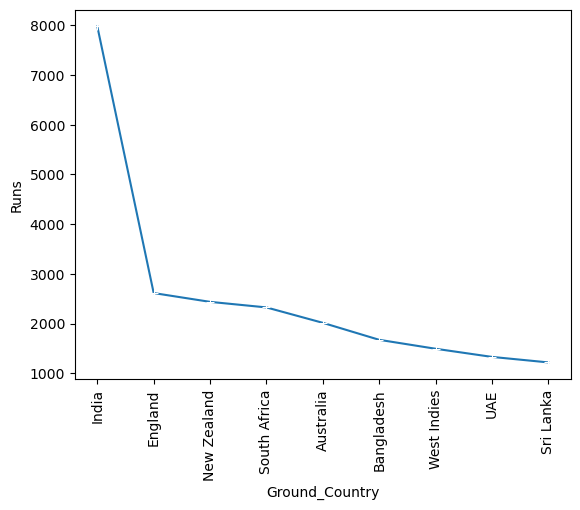

In [508]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=most_runs_country_in_international,
    x="Ground_Country",
    y="Runs",
    marker='+',
    linestyle='--'
)

plt.title("Total Runs against the Opponents")
plt.xlabel("Opponents")
plt.ylabel("Runs Scored")
plt.xticks(rotation=90)
plt.show()


In [309]:
most_centriues_opponent=dfl.groupby("Opponent")[["Hundreds"]].sum().sort_values(by="Hundreds",ascending=False).reset_index()
most_centriues_opponent

,Opponent,Hundreds
0,England,6
1,New Zealand,6
2,Sri Lanka,4
3,Nepal,3
4,South Africa,3
5,Afghanistan,2
6,Australia,2
7,Bangladesh,2
8,Ireland,2
9,Pakistan,2


C:\Users\Karthikeya\AppData\Local\Temp\ipykernel_45696\1007220859.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_centriues_opponent["Opponent"],y=most_centriues_opponent["Hundreds"],palette="Set2")


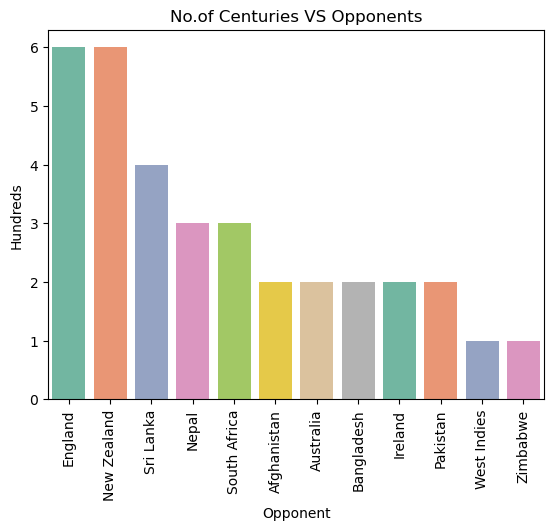

In [498]:
sns.barplot(x=most_centriues_opponent["Opponent"],y=most_centriues_opponent["Hundreds"],palette="Set2")
plt.xticks(rotation=90)
plt.title("No.of Centuries VS Opponents")
plt.show()

In [492]:
opponent_wise_inruns=dfl.groupby("Opponent")[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
opponent_wise_inruns

,Opponent,Runs
0,New Zealand,2429
1,Pakistan,2405
2,Nepal,2325
3,Sri Lanka,2152
4,England,2010
5,Bangladesh,1952
6,Afghanistan,1830
7,Ireland,1740
8,Australia,1702
9,West Indies,1618


C:\Users\Karthikeya\AppData\Local\Temp\ipykernel_45696\3866565021.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=opponent_wise_inruns,x="Opponent",y="Runs",palette="Set2")


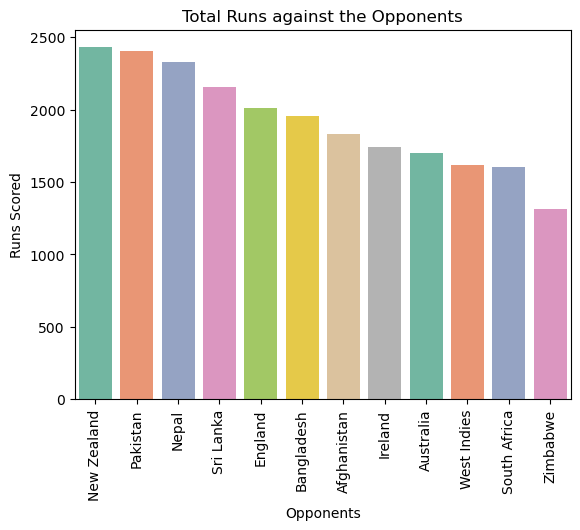

In [494]:
sns.barplot(data=opponent_wise_inruns,x="Opponent",y="Runs",palette="Set2")
plt.title("Total Runs against the Opponents")
plt.xlabel("Opponents")
plt.ylabel("Runs Scored")
plt.xticks(rotation=90)
plt.show()

In [259]:
dfO=df[df["Format"]=="ODI"]
dfO

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
0,2007,ODI,International Cricket,India,England,Kingsmead,South Africa,No,122,183,66.67,Run Out,Out,Won,1,1,1,0,0,1
1,2007,ODI,International Cricket,India,Afghanistan,M. Chinnaswamy Stadium,India,No,95,125,76.00,LBW,Out,Won,1,1,0,0,1,1
5,2007,ODI,International Cricket,India,Afghanistan,Arun Jaitley Stadium,India,No,33,37,89.19,Bowled,Out,Lost,1,1,0,0,0,0
8,2007,ODI,International Cricket,India,Bangladesh,St George's Park,South Africa,No,39,59,66.10,Caught,Out,Won,1,1,0,0,0,1
9,2007,ODI,International Cricket,India,New Zealand,Wanderers Stadium,South Africa,No,2,9,22.22,Caught,Out,Won,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,2026,ODI,International Cricket,India,England,The Gabba,Australia,No,29,34,85.29,Bowled,Out,Won,1,1,0,0,0,1
990,2026,ODI,International Cricket,India,England,Sabina Park,West Indies,No,17,21,80.95,Caught,Out,Lost,1,1,0,0,0,0
991,2026,ODI,International Cricket,India,Pakistan,Arun Jaitley Stadium,India,No,5,1,500.00,Caught,Out,Won,1,1,0,0,0,1
997,2026,ODI,International Cricket,India,West Indies,Kingsmead,South Africa,No,58,68,85.29,Bowled,Out,Lost,1,1,0,0,1,0


In [271]:
opponent_wise_ODIruns=dfO.groupby(["Year"])[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
opponent_wise_ODIruns.head(5)

,Year,Runs
0,2019,1621
1,2024,1289
2,2020,1278
3,2021,1196
4,2014,1128


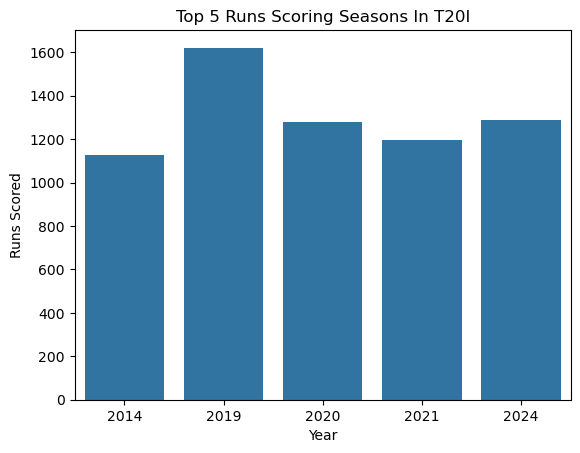

In [484]:
sns.barplot(data=opponent_wise_ODIruns.head(5),x="Year",y="Runs")
plt.title("Top 5 Runs Scoring Seasons In T20I")
plt.xlabel("Year")
plt.ylabel("Runs Scored")
plt.show()

In [281]:
dfT=df[df["Format"]=="T20I"]


In [480]:
opponent_wise_T20runs=dfT.groupby(["Year"])[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
opponent_wise_T20runs=opponent_wise_T20runs.head(5)
opponent_wise_T20runs

,Year,Runs
0,2020,282
1,2017,272
2,2022,181
3,2024,180
4,2021,173


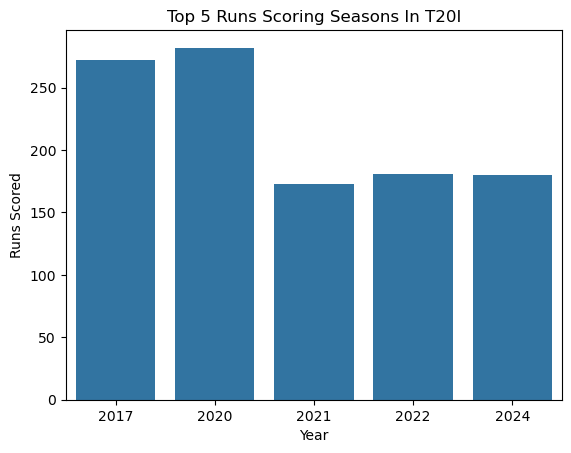

In [482]:
sns.barplot(data=opponent_wise_T20runs,x="Year",y="Runs")
plt.title("Top 5 Runs Scoring Seasons In T20I")
plt.xlabel("Year")
plt.ylabel("Runs Scored")
plt.show()

In [476]:
dfTest=df[df["Format"]=="Test"]

opponent_wise_Testruns=dfTest.groupby(["Year"])[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
opponent_wise_Testruns=opponent_wise_Testruns.head(5)
opponent_wise_Testruns

,Year,Runs
0,2026,317
1,2021,296
2,2022,272
3,2016,233
4,2020,222


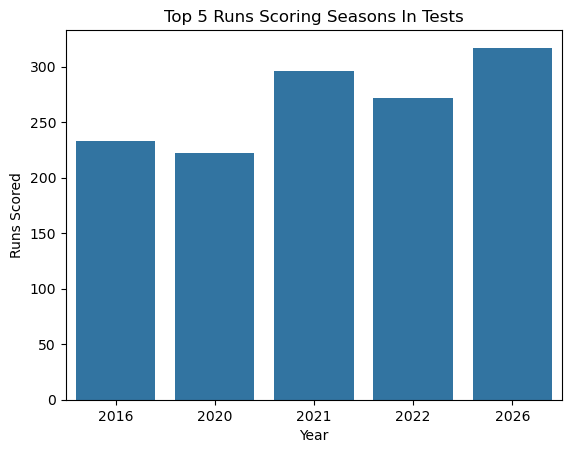

In [478]:
sns.barplot(data=opponent_wise_Testruns,x="Year",y="Runs")
plt.title("Top 5 Runs Scoring Seasons In Tests")
plt.xlabel("Year")
plt.ylabel("Runs Scored")
plt.show()

In [229]:
dflw=df[(df["League"]=="International Cricket") & (df["Match_Result"]=="Won")]
dflw

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
0,2007,ODI,International Cricket,India,England,Kingsmead,South Africa,No,122,183,66.67,Run Out,Out,Won,1,1,1,0,0,1
1,2007,ODI,International Cricket,India,Afghanistan,M. Chinnaswamy Stadium,India,No,95,125,76.00,LBW,Out,Won,1,1,0,0,1,1
8,2007,ODI,International Cricket,India,Bangladesh,St George's Park,South Africa,No,39,59,66.10,Caught,Out,Won,1,1,0,0,0,1
9,2007,ODI,International Cricket,India,New Zealand,Wanderers Stadium,South Africa,No,2,9,22.22,Caught,Out,Won,1,1,0,0,0,1
11,2007,ODI,International Cricket,India,New Zealand,M. Chinnaswamy Stadium,India,No,20,27,74.07,Caught,Out,Won,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2026,ODI,International Cricket,India,Bangladesh,Eden Gardens,India,No,6,14,42.86,Caught,Out,Won,1,1,0,0,0,1
988,2026,ODI,International Cricket,India,England,The Gabba,Australia,No,29,34,85.29,Bowled,Out,Won,1,1,0,0,0,1
991,2026,ODI,International Cricket,India,Pakistan,Arun Jaitley Stadium,India,No,5,1,500.00,Caught,Out,Won,1,1,0,0,0,1
998,2026,ODI,International Cricket,India,Bangladesh,Wankhede Stadium,India,No,19,17,111.76,Caught,Out,Won,1,1,0,0,0,1


In [299]:
opponent_wise_wins=dfl.groupby("Opponent")[["Innings","Match_Status"]].sum().sort_values(by="Match_Status",ascending=False).reset_index()
opponent_wise_wins

,Opponent,Innings,Match_Status
0,New Zealand,56,42
1,Pakistan,65,42
2,Bangladesh,53,37
3,Ireland,55,37
4,Australia,51,36
5,Nepal,58,36
6,West Indies,46,29
7,England,49,28
8,South Africa,45,28
9,Sri Lanka,52,27


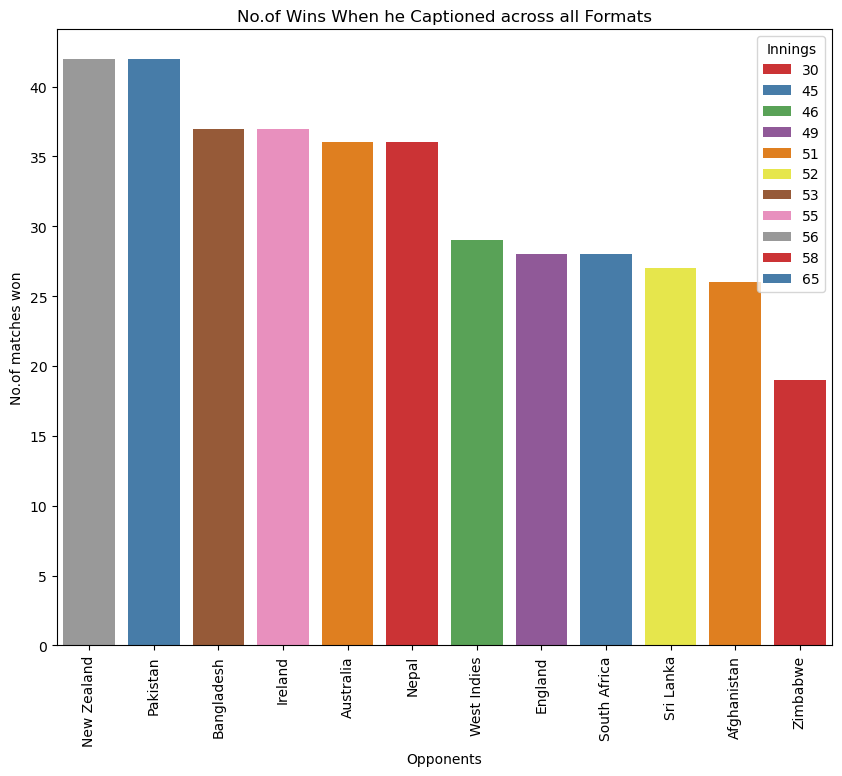

In [474]:
plt.figure(figsize=(10,8))
sns.barplot(data=opponent_wise_wins,x="Opponent",y="Match_Status",hue="Innings",palette="Set1")
plt.title("No.of Wins When he Captioned across all Formats")
plt.xlabel("Opponents")
plt.xticks(rotation=90)
plt.ylabel("No.of matches won")
plt.show()

In [233]:
dfll=df[(df["League"]=="International Cricket") & (df["Match_Result"]=="Lost")]
dfll

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
5,2007,ODI,International Cricket,India,Afghanistan,Arun Jaitley Stadium,India,No,33,37,89.19,Bowled,Out,Lost,1,1,0,0,0,0
6,2007,Test,International Cricket,India,South Africa,Arun Jaitley Stadium,India,No,59,97,60.82,Caught,Out,Lost,1,1,0,0,1,0
10,2007,ODI,International Cricket,India,Sri Lanka,Rajiv Gandhi International Stadium,India,No,31,29,106.90,LBW,Out,Lost,1,1,0,0,0,0
15,2007,ODI,International Cricket,India,Ireland,Melbourne Cricket Ground,Australia,No,79,112,70.54,Not Out,Not Out,Lost,1,1,0,0,1,0
17,2007,ODI,International Cricket,India,Bangladesh,Arun Jaitley Stadium,India,No,37,54,68.52,LBW,Out,Lost,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983,2026,Test,International Cricket,India,Bangladesh,Queen's Park Oval,West Indies,No,19,79,24.05,Caught,Out,Lost,1,1,0,0,0,0
985,2026,ODI,International Cricket,India,Bangladesh,Wanderers Stadium,South Africa,No,44,44,100.00,Not Out,Not Out,Lost,1,1,0,0,0,0
990,2026,ODI,International Cricket,India,England,Sabina Park,West Indies,No,17,21,80.95,Caught,Out,Lost,1,1,0,0,0,0
995,2026,T20I,International Cricket,India,Nepal,Sher-e-Bangla National Cricket Stadium,Bangladesh,No,16,18,88.89,Caught,Out,Lost,1,1,0,0,0,0


In [235]:
opponent_wise_Lost=dfll.groupby("Opponent")[["Match_Result"]].value_counts().sort_values(ascending=False).reset_index()
opponent_wise_Lost

,Opponent,Match_Result,count
0,Afghanistan,Lost,25
1,Sri Lanka,Lost,25
2,Pakistan,Lost,23
3,Nepal,Lost,22
4,England,Lost,21
5,Ireland,Lost,18
6,South Africa,Lost,17
7,West Indies,Lost,17
8,Bangladesh,Lost,16
9,Australia,Lost,15


In [237]:
dfI=df[df["League"]=="Indian Premier League"]
dfI

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
2,2007,IPL,Indian Premier League,Deccan Chargers,Chennai Super Kings,Arun Jaitley Stadium,India,No,19,14,135.71,Bowled,Out,Won,1,1,0,0,0,1
3,2007,IPL,Indian Premier League,Mumbai Indians,Lucknow Super Giants,Arun Jaitley Stadium,India,No,34,27,125.93,Caught,Out,Won,1,1,0,0,0,1
4,2007,IPL,Indian Premier League,Deccan Chargers,Lucknow Super Giants,Arun Jaitley Stadium,India,No,57,62,91.94,Caught,Out,Won,1,1,0,0,1,1
7,2007,IPL,Indian Premier League,Mumbai Indians,Lucknow Super Giants,Wankhede Stadium,India,No,7,1,700.00,Caught,Out,Won,1,1,0,0,0,1
13,2007,IPL,Indian Premier League,Mumbai Indians,Punjab Kings,Narendra Modi Stadium,India,No,47,40,117.50,Run Out,Out,Won,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,2026,IPL,Indian Premier League,Deccan Chargers,Punjab Kings,Eden Gardens,India,No,51,40,127.50,Caught,Out,Won,1,1,0,0,1,1
992,2026,IPL,Indian Premier League,Mumbai Indians,Rajasthan Royals,Eden Gardens,India,Yes,18,21,85.71,Bowled,Out,Won,1,1,0,0,0,1
993,2026,IPL,Indian Premier League,Mumbai Indians,Sunrisers Hyderabad,Rajiv Gandhi International Stadium,India,Yes,44,29,151.72,LBW,Out,Lost,1,1,0,0,0,0
994,2026,IPL,Indian Premier League,Mumbai Indians,Royal Challengers Bengaluru,Wankhede Stadium,India,Yes,24,19,126.32,Caught,Out,Won,1,1,0,0,0,1


In [241]:
opponent_wise_Iruns=dfI.groupby("Opponent")[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
opponent_wise_Iruns

,Opponent,Runs
0,Chennai Super Kings,1561
1,Lucknow Super Giants,1306
2,Punjab Kings,1253
3,Gujarat Titans,1185
4,Sunrisers Hyderabad,1122
5,Royal Challengers Bengaluru,1120
6,Delhi Capitals,985
7,Kolkata Knight Riders,877
8,Rajasthan Royals,754


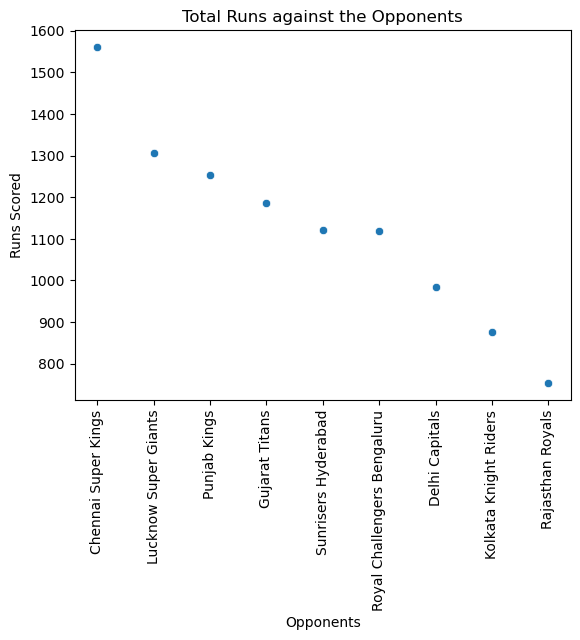

In [462]:
sns.scatterplot(data=opponent_wise_Iruns,x="Opponent",y="Runs",marker='o')
plt.title("Total Runs against the Opponents")
plt.xlabel("Opponents")
plt.ylabel("Runs Scored")
plt.xticks(rotation=90)
plt.show()

In [247]:
opponent_wise_ISR=dfI.groupby("Opponent")[["Strike_Rate"]].mean().sort_values(by="Strike_Rate",ascending=False).reset_index()
opponent_wise_ISR

,Opponent,Strike_Rate
0,Sunrisers Hyderabad,124.225111
1,Lucknow Super Giants,109.956731
2,Kolkata Knight Riders,109.616216
3,Royal Challengers Bengaluru,107.806136
4,Punjab Kings,100.587255
5,Chennai Super Kings,99.601304
6,Gujarat Titans,95.550750
7,Delhi Capitals,94.405952
8,Rajasthan Royals,86.046250


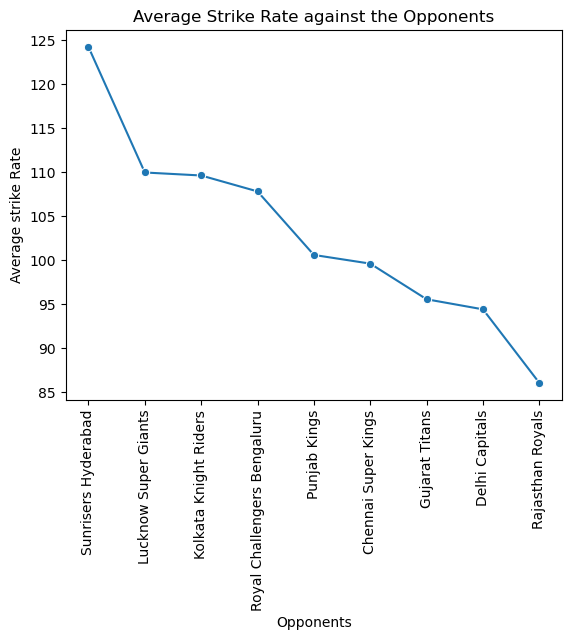

In [452]:
sns.lineplot(data=opponent_wise_ISR,x="Opponent",y="Strike_Rate",marker='o')
plt.title("Average Strike Rate against the Opponents")
plt.xlabel("Opponents")
plt.ylabel("Average strike Rate")
plt.xticks(rotation=90)
plt.show()

In [440]:
opponent_wise_Yruns=dfI.groupby("Year")[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
opponent_wise_Yruns=opponent_wise_Yruns.head(5)
opponent_wise_Yruns

,Year,Runs
0,2020,880
1,2019,738
2,2017,677
3,2013,659
4,2024,631


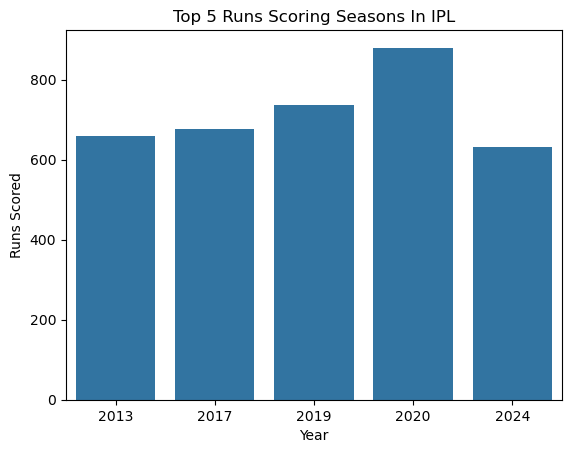

In [444]:
sns.barplot(data=opponent_wise_Yruns,x="Year",y="Runs")
plt.title("Top 5 Runs Scoring Seasons In IPL")
plt.xlabel("Year")
plt.ylabel("Runs Scored")
plt.show()

In [315]:
dfIW=df[(df["League"]=="Indian Premier League")&(df["Captain"]=="Yes")]
dfIW

,Year,Format,League,Team,Opponent,Ground_Name,Ground_Country,Captain,Runs,Balls,Strike_Rate,Dismissal,Out_Status,Match_Result,Innings,Outs/NotOut,Hundreds,Double_Hundreds,Fifties,Match_Status
248,2013,IPL,Indian Premier League,Mumbai Indians,Gujarat Titans,Arun Jaitley Stadium,India,Yes,44,45,97.78,Not Out,Not Out,Lost,1,1,0,0,0,0
249,2013,IPL,Indian Premier League,Mumbai Indians,Gujarat Titans,MA Chidambaram Stadium,India,Yes,9,6,150.00,Caught,Out,Won,1,1,0,0,0,1
252,2013,IPL,Indian Premier League,Mumbai Indians,Rajasthan Royals,Wankhede Stadium,India,Yes,49,36,136.11,Caught,Out,Lost,1,1,0,0,0,0
254,2013,IPL,Indian Premier League,Mumbai Indians,Punjab Kings,MA Chidambaram Stadium,India,Yes,17,15,113.33,Caught,Out,Won,1,1,0,0,0,1
263,2013,IPL,Indian Premier League,Mumbai Indians,Chennai Super Kings,Eden Gardens,India,Yes,34,30,113.33,Bowled,Out,Lost,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,2026,IPL,Indian Premier League,Mumbai Indians,Rajasthan Royals,Wankhede Stadium,India,Yes,28,34,82.35,Caught,Out,Won,1,1,0,0,0,1
984,2026,IPL,Indian Premier League,Mumbai Indians,Sunrisers Hyderabad,Eden Gardens,India,Yes,53,57,92.98,Not Out,Not Out,Lost,1,1,0,0,1,0
992,2026,IPL,Indian Premier League,Mumbai Indians,Rajasthan Royals,Eden Gardens,India,Yes,18,21,85.71,Bowled,Out,Won,1,1,0,0,0,1
993,2026,IPL,Indian Premier League,Mumbai Indians,Sunrisers Hyderabad,Rajiv Gandhi International Stadium,India,Yes,44,29,151.72,LBW,Out,Lost,1,1,0,0,0,0


In [317]:
most_wins_opp=dfIW.groupby("Opponent")[["Innings","Match_Status"]].sum().sort_values(by="Match_Status",ascending=False).reset_index()
most_wins_opp

,Opponent,Innings,Match_Status
0,Punjab Kings,19,16
1,Chennai Super Kings,20,14
2,Lucknow Super Giants,22,14
3,Rajasthan Royals,18,11
4,Delhi Capitals,14,10
5,Gujarat Titans,14,9
6,Kolkata Knight Riders,13,7
7,Royal Challengers Bengaluru,17,6
8,Sunrisers Hyderabad,19,6


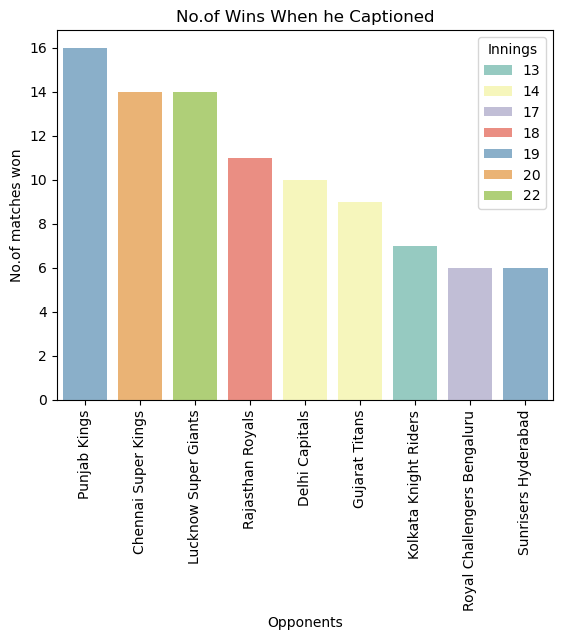

In [438]:
sns.barplot(data=most_wins_opp,x="Opponent",y="Match_Status",hue="Innings",palette="Set3")
plt.title("No.of Wins When he Captioned")
plt.xlabel("Opponents")
plt.xticks(rotation=90)
plt.ylabel("No.of matches won")
plt.show()

In [301]:
most_runs_stadium=dfI.groupby("Ground_Name")[["Runs"]].sum().sort_values(by="Runs",ascending=False).reset_index()
most_runs_stadium

,Ground_Name,Runs
0,Arun Jaitley Stadium,1820
1,Rajiv Gandhi International Stadium,1619
2,Wankhede Stadium,1564
3,Eden Gardens,1336
4,M. Chinnaswamy Stadium,1316
5,Narendra Modi Stadium,1256
6,MA Chidambaram Stadium,1252


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Arun Jaitley Stadium'),
  Text(1, 0, 'Rajiv Gandhi International Stadium'),
  Text(2, 0, 'Wankhede Stadium'),
  Text(3, 0, 'Eden Gardens'),
  Text(4, 0, 'M. Chinnaswamy Stadium'),
  Text(5, 0, 'Narendra Modi Stadium'),
  Text(6, 0, 'MA Chidambaram Stadium')])

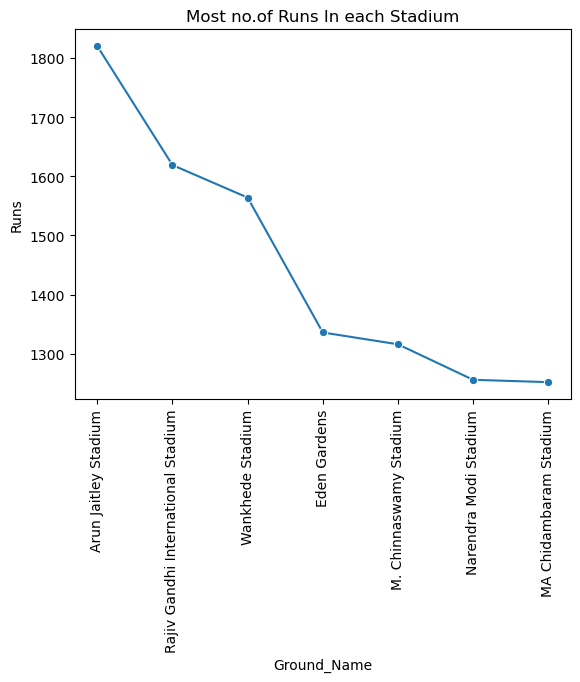

In [436]:
sns.lineplot(x="Ground_Name",y="Runs",data=most_runs_stadium,marker='o')
plt.title("Most no.of Runs In each Stadium")
plt.xticks(rotation=90)

In [313]:
most_centriues_opponent_inIPL=dfI.groupby("Opponent")[["Hundreds"]].sum().sort_values(by="Hundreds",ascending=False).reset_index()
most_centriues_opponent_inIPL

,Opponent,Hundreds
0,Chennai Super Kings,4
1,Gujarat Titans,1
2,Delhi Capitals,0
3,Kolkata Knight Riders,0
4,Lucknow Super Giants,0
5,Punjab Kings,0
6,Rajasthan Royals,0
7,Royal Challengers Bengaluru,0
8,Sunrisers Hyderabad,0


C:\Users\Karthikeya\AppData\Local\Temp\ipykernel_45696\2126461830.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_centriues_opponent_inIPL["Opponent"],y=most_centriues_opponent_inIPL["Hundreds"],palette="Set2")


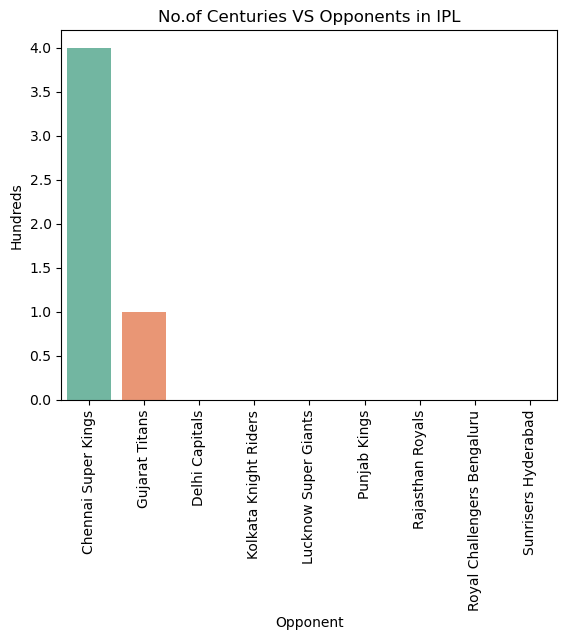

In [430]:
sns.barplot(x=most_centriues_opponent_inIPL["Opponent"],y=most_centriues_opponent_inIPL["Hundreds"],palette="Set2")
plt.xticks(rotation=90)
plt.title("No.of Centuries VS Opponents in IPL")
plt.show()